In [1]:
import pandas as pd
import sqlite3

# Connect to the Northwind database
conn = sqlite3.connect("../database/northwind.db")

print("✅ Connected successfully!")

✅ Connected successfully!


In [2]:
import pandas as pd
import sqlite3

# Connect to the Northwind database
conn = sqlite3.connect("../database/northwind.db")
print("✅ Connected successfully!")

# Load Products table into a DataFrame
products = pd.read_sql_query(
    "SELECT * FROM Products",
    conn
)

# Display first 5 rows
products.head()

✅ Connected successfully!


,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued
0,1,Chai,1,1,10 boxes x 20 bags,18.00,39,0,10,0
1,2,Chang,1,1,24 - 12 oz bottles,19.00,17,40,25,0
2,3,Aniseed Syrup,1,2,12 - 550 ml bottles,10.00,13,70,25,0
3,4,Chef Anton's Cajun Seasoning,2,2,48 - 6 oz jars,22.00,53,0,0,0
4,5,Chef Anton's Gumbo Mix,2,2,36 boxes,21.35,0,0,0,1


# Northwind Sales Analysis

## Business Analysis using SQL and Pandas

**Dataset:** Northwind Database

**Author:** Anandan M A

---

### Objectives

- Analyze Top Selling Products
- Find Top Customers by Revenue
- Analyze Monthly Sales Trends
- Find Best Performing Product Categories
- Analyze Customer Purchase Frequency

In [3]:
# Explore the Products table

print("Shape:", products.shape)

print("\nColumns:")
print(products.columns.tolist())

print("\nData Types:")
print(products.dtypes)

print("\nMissing Values:")
print(products.isnull().sum())

Shape: (77, 10)

Columns:
['ProductID', 'ProductName', 'SupplierID', 'CategoryID', 'QuantityPerUnit', 'UnitPrice', 'UnitsInStock', 'UnitsOnOrder', 'ReorderLevel', 'Discontinued']

Data Types:
ProductID            int64
ProductName         object
SupplierID           int64
CategoryID           int64
QuantityPerUnit     object
UnitPrice          float64
UnitsInStock         int64
UnitsOnOrder         int64
ReorderLevel         int64
Discontinued        object
dtype: object

Missing Values:
ProductID          0
ProductName        0
SupplierID         0
CategoryID         0
QuantityPerUnit    0
UnitPrice          0
UnitsInStock       0
UnitsOnOrder       0
ReorderLevel       0
Discontinued       0
dtype: int64


In [4]:
# Product statistics

print("Total Products:", len(products))

print("\nAverage Product Price:")
print(products["UnitPrice"].mean())

print("\nMost Expensive Product:")
print(products.loc[products["UnitPrice"].idxmax()])

print("\nLeast Expensive Product:")
print(products.loc[products["UnitPrice"].idxmin()])

Total Products: 77

Average Product Price:
28.866363636363637

Most Expensive Product:
ProductID                          38
ProductName             Côte de Blaye
SupplierID                         18
CategoryID                          1
QuantityPerUnit    12 - 75 cl bottles
UnitPrice                       263.5
UnitsInStock                       17
UnitsOnOrder                        0
ReorderLevel                       15
Discontinued                        0
Name: 37, dtype: object

Least Expensive Product:
ProductID               33
ProductName        Geitost
SupplierID              15
CategoryID               4
QuantityPerUnit      500 g
UnitPrice              2.5
UnitsInStock           112
UnitsOnOrder             0
ReorderLevel            20
Discontinued             0
Name: 32, dtype: object


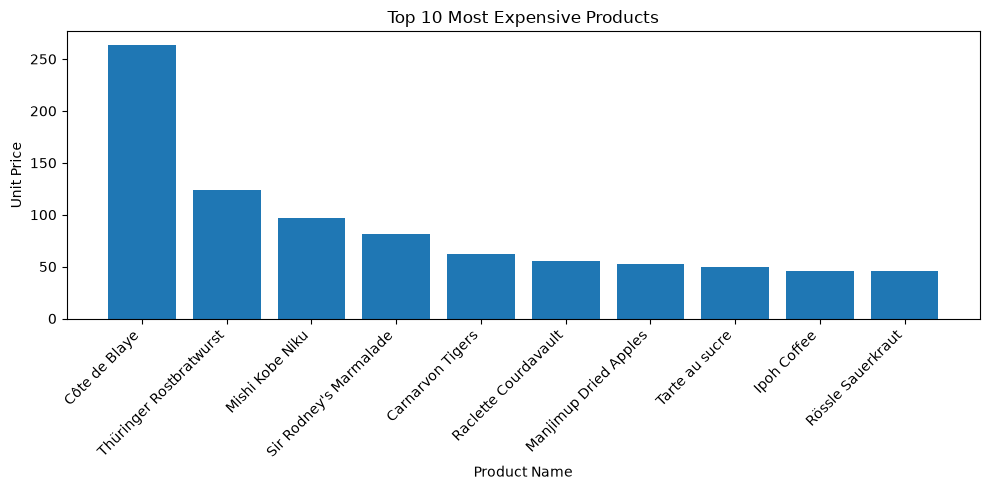

In [5]:
import matplotlib.pyplot as plt

# Top 10 most expensive products
top10 = products.nlargest(10, "UnitPrice")

plt.figure(figsize=(10,5))
plt.bar(top10["ProductName"], top10["UnitPrice"])
plt.title("Top 10 Most Expensive Products")
plt.xlabel("Product Name")
plt.ylabel("Unit Price")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [6]:
import sys
print(sys.executable)


C:\Users\OMEN\AppData\Local\Programs\Python\Python313\python.exe


In [7]:
# Top 10 Best Selling Products

top_selling = (
    products.sort_values("UnitsInStock", ascending=False)
            [["ProductName", "UnitsInStock"]]
            .head(10)
)

print(top_selling)

                     ProductName  UnitsInStock
74          Rhönbräu Klosterbier           125
39              Boston Crab Meat           123
5   Grandma's Boysenberry Spread           120
54                  Pâté chinois           115
60                Sirop d'érable           113
32                       Geitost           112
35                   Inlagd Sill           112
33                 Sasquatch Ale           111
21           Gustaf's Knäckebröd           104
72                    Röd Kaviar           101


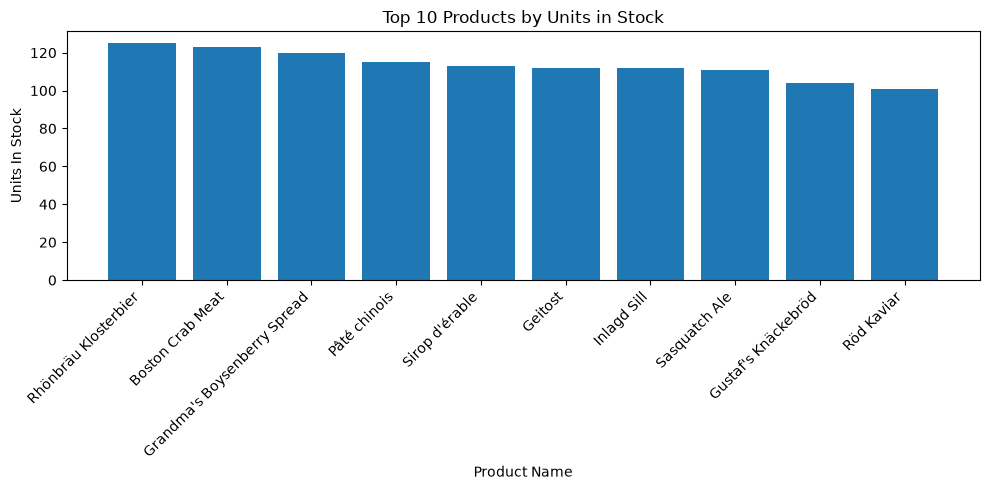

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(top_selling["ProductName"], top_selling["UnitsInStock"])

plt.title("Top 10 Products by Units in Stock")
plt.xlabel("Product Name")
plt.ylabel("Units In Stock")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

In [9]:
query = """
SELECT
    strftime('%Y-%m', o.OrderDate) AS Month,
    ROUND(SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)),2) AS TotalSales
FROM Orders o
JOIN "Order Details" od
ON o.OrderID = od.OrderID
GROUP BY Month
ORDER BY Month;
"""

monthly_sales = pd.read_sql_query(query, conn)

monthly_sales.head()

,Month,TotalSales
0,2012-07,2066219.40
1,2012-08,3556875.79
2,2012-09,3440144.98
3,2012-10,3201529.96
4,2012-11,2980494.74


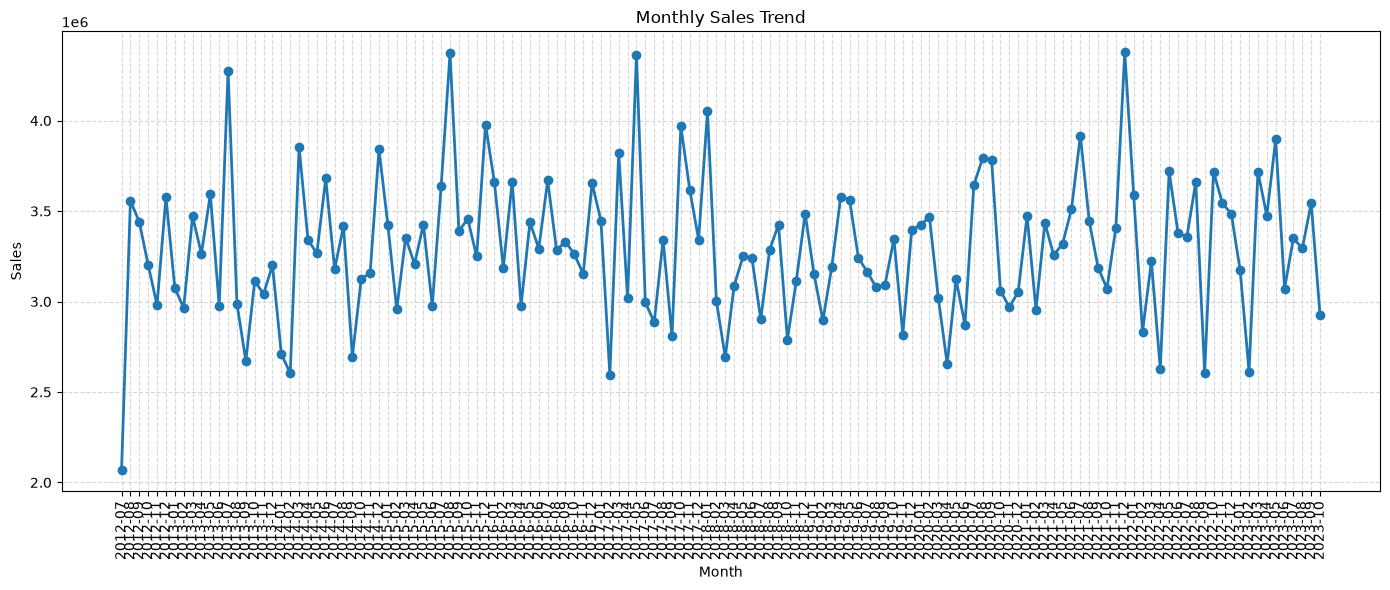

In [10]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_sales["Month"],
    monthly_sales["TotalSales"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=90)

plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [11]:
query = """
SELECT
    c.CompanyName,
    ROUND(SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)),2) AS Revenue
FROM Customers c
JOIN Orders o
    ON c.CustomerID = o.CustomerID
JOIN "Order Details" od
    ON o.OrderID = od.OrderID
GROUP BY c.CompanyName
ORDER BY Revenue DESC
LIMIT 10;
"""

top_customers = pd.read_sql_query(query, conn)

top_customers

,CompanyName,Revenue
0,IT,9745371.29
1,B's Beverages,6154115.34
2,Hungry Coyote Import Store,5698023.67
3,Rancho grande,5559110.08
4,Gourmet Lanchonetes,5552309.80
5,Ana Trujillo Emparedados y helados,5534356.65
6,Ricardo Adocicados,5524517.31
7,Folies gourmandes,5505502.85
8,Let's Stop N Shop,5462198.02
9,LILA-Supermercado,5437438.34


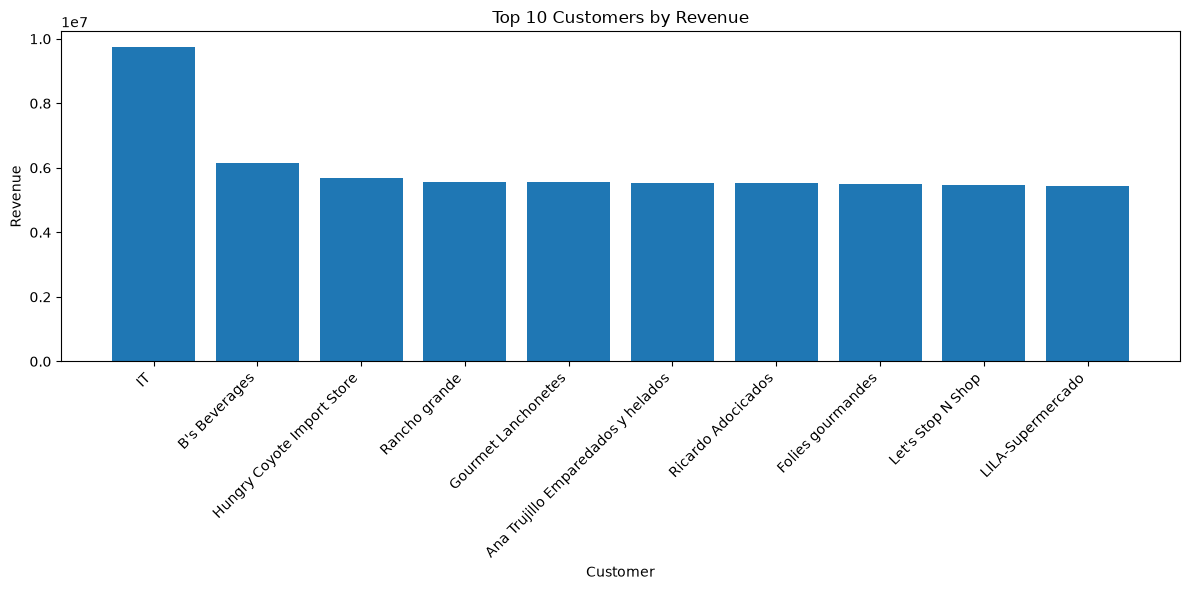

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(top_customers["CompanyName"], top_customers["Revenue"])

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer")
plt.ylabel("Revenue")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

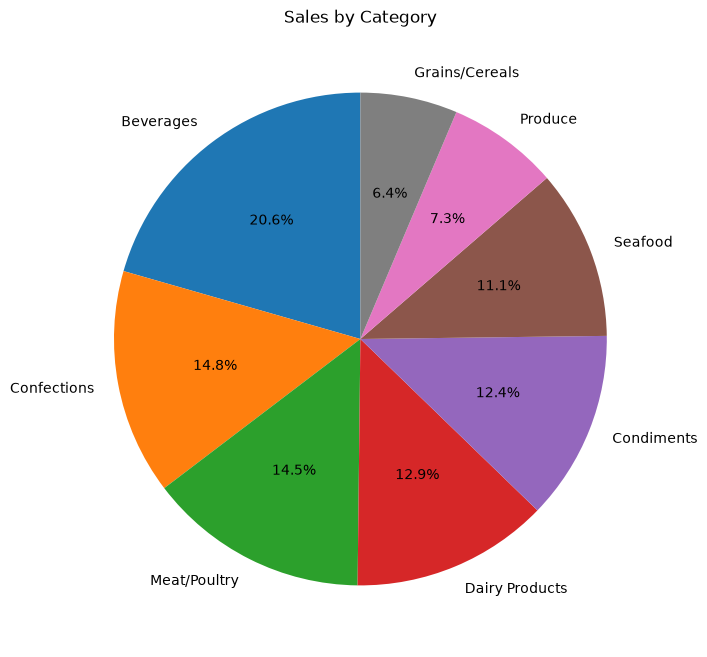

In [13]:
# Sales by Category

query = """
SELECT
    c.CategoryName,
    ROUND(SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)),2) AS Revenue
FROM Categories c
JOIN Products p
    ON c.CategoryID = p.CategoryID
JOIN "Order Details" od
    ON p.ProductID = od.ProductID
GROUP BY c.CategoryName
ORDER BY Revenue DESC;
"""

category_sales = pd.read_sql_query(query, conn)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

plt.pie(
    category_sales["Revenue"],
    labels=category_sales["CategoryName"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Sales by Category")

plt.show()

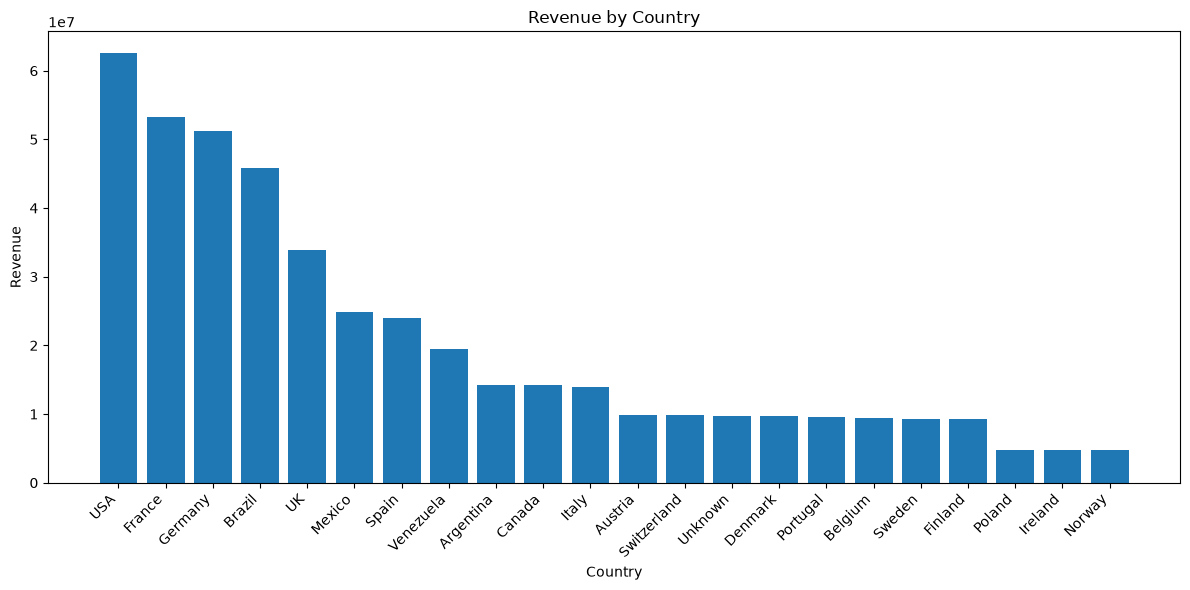

In [16]:
# Revenue by Country

query = """
SELECT
    c.Country,
    ROUND(SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)), 2) AS Revenue
FROM Customers c
JOIN Orders o
    ON c.CustomerID = o.CustomerID
JOIN "Order Details" od
    ON o.OrderID = od.OrderID
GROUP BY c.Country
ORDER BY Revenue DESC;
"""

# Load SQL result into a DataFrame
country_sales = pd.read_sql_query(query, conn)

# Replace missing country names
country_sales["Country"] = country_sales["Country"].fillna("Unknown")

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.bar(country_sales["Country"], country_sales["Revenue"])

plt.title("Revenue by Country")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [ ]:
# Revenue by Country

query = """
SELECT
    c.Country,
    ROUND(SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)), 2) AS Revenue
FROM Customers c
JOIN Orders o
    ON c.CustomerID = o.CustomerID
JOIN "Order Details" od
    ON o.OrderID = od.OrderID
GROUP BY c.Country
ORDER BY Revenue DESC;
"""

# Load SQL result into a DataFrame
country_sales = pd.read_sql_query(query, conn)

# Replace missing country names
country_sales["Country"] = country_sales["Country"].fillna("Unknown")

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.bar(country_sales["Country"], country_sales["Revenue"])

plt.title("Revenue by Country")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

NameError: name 'country_sales' is not defined

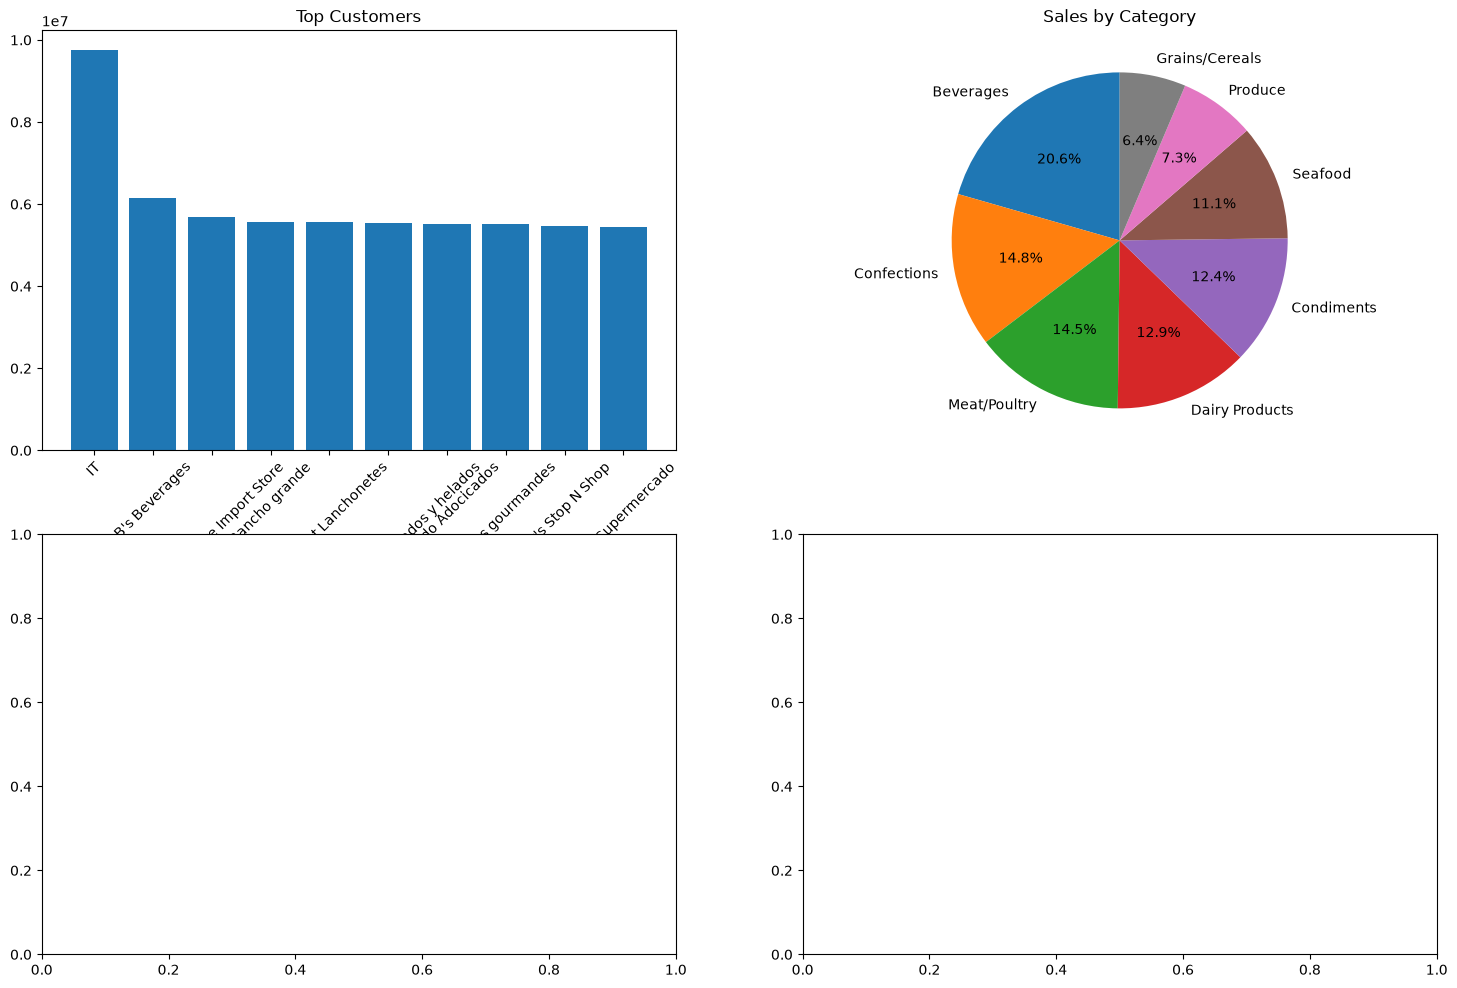

In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 2, figsize=(18,12))

# -------------------------------
# Top Customers
# -------------------------------
ax[0,0].bar(
    top_customers["CompanyName"],
    top_customers["Revenue"]
)
ax[0,0].set_title("Top Customers")
ax[0,0].tick_params(axis="x", rotation=45)

# -------------------------------
# Sales by Category
# -------------------------------
ax[0,1].pie(
    category_sales["Revenue"],
    labels=category_sales["CategoryName"],
    autopct="%1.1f%%",
    startangle=90
)
ax[0,1].set_title("Sales by Category")

# -------------------------------
# Revenue by Country
# -------------------------------
ax[1,0].bar(
    country_sales["Country"],
    country_sales["Revenue"]
)
ax[1,0].set_title("Revenue by Country")
ax[1,0].tick_params(axis="x", rotation=45)

# -------------------------------
# Revenue by Product Category
# -------------------------------
ax[1,1].barh(
    category_revenue["CategoryName"],
    category_revenue["Revenue"]
)
ax[1,1].set_title("Revenue by Product Category")

plt.tight_layout()

plt.show()

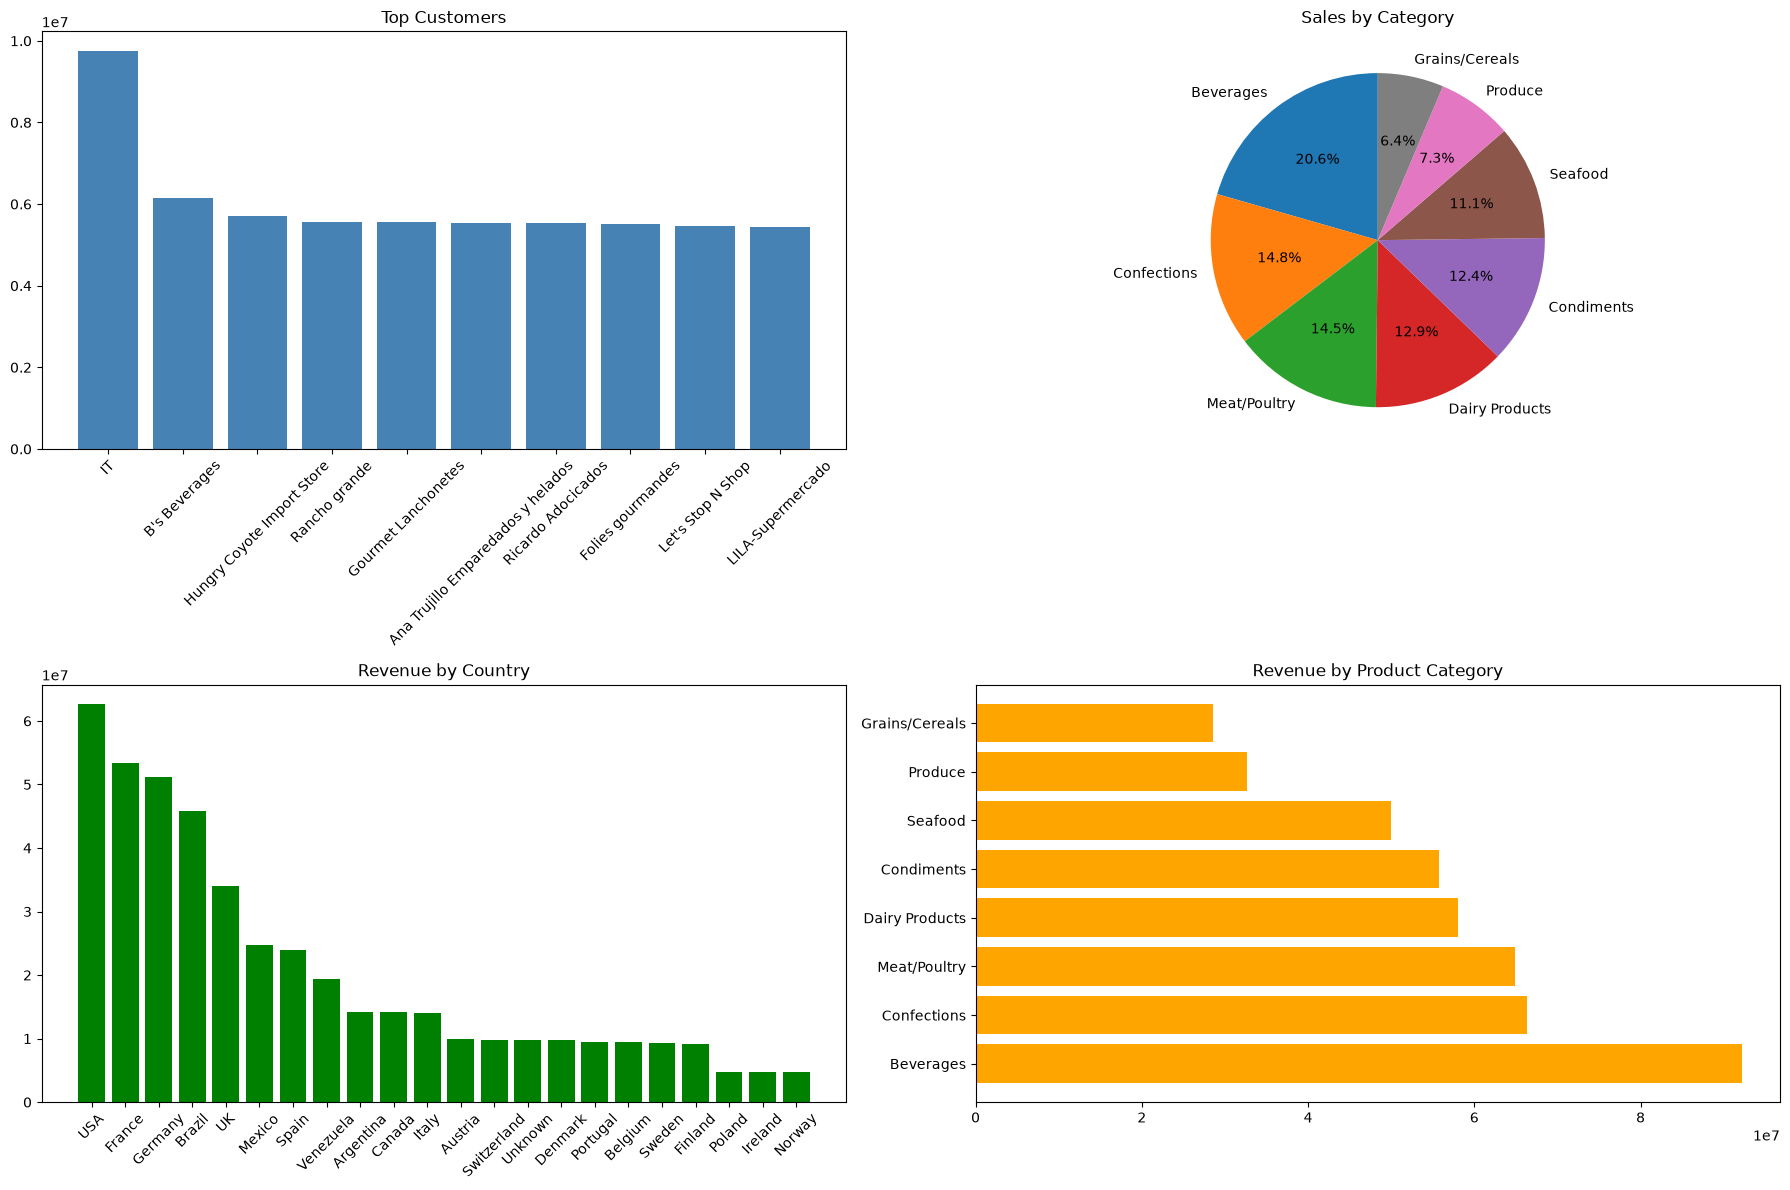

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------
# Top Customers
# ---------------------------------
query = """
SELECT
    c.CompanyName,
    ROUND(SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)),2) AS Revenue
FROM Customers c
JOIN Orders o
    ON c.CustomerID = o.CustomerID
JOIN "Order Details" od
    ON o.OrderID = od.OrderID
GROUP BY c.CompanyName
ORDER BY Revenue DESC
LIMIT 10;
"""
top_customers = pd.read_sql_query(query, conn)

# ---------------------------------
# Sales by Category
# ---------------------------------
query = """
SELECT
    c.CategoryName,
    ROUND(SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)),2) AS Revenue
FROM Categories c
JOIN Products p
    ON c.CategoryID = p.CategoryID
JOIN "Order Details" od
    ON p.ProductID = od.ProductID
GROUP BY c.CategoryName
ORDER BY Revenue DESC;
"""
category_sales = pd.read_sql_query(query, conn)

# ---------------------------------
# Revenue by Country
# ---------------------------------
query = """
SELECT
    cu.Country,
    ROUND(SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)),2) AS Revenue
FROM Customers cu
JOIN Orders o
    ON cu.CustomerID = o.CustomerID
JOIN "Order Details" od
    ON o.OrderID = od.OrderID
GROUP BY cu.Country
ORDER BY Revenue DESC;
"""
country_sales = pd.read_sql_query(query, conn)

country_sales["Country"] = country_sales["Country"].fillna("Unknown")

# ---------------------------------
# Revenue by Product Category
# ---------------------------------
query = """
SELECT
    c.CategoryName,
    ROUND(SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)),2) AS Revenue
FROM Categories c
JOIN Products p
    ON c.CategoryID = p.CategoryID
JOIN "Order Details" od
    ON p.ProductID = od.ProductID
GROUP BY c.CategoryName
ORDER BY Revenue DESC;
"""
category_revenue = pd.read_sql_query(query, conn)

# =================================
# VISUALIZATIONS
# =================================

fig, ax = plt.subplots(2, 2, figsize=(18,12))

# Top Customers
ax[0,0].bar(
    top_customers["CompanyName"],
    top_customers["Revenue"],
    color="steelblue"
)
ax[0,0].set_title("Top Customers")
ax[0,0].tick_params(axis="x", rotation=45)

# Sales by Category
ax[0,1].pie(
    category_sales["Revenue"],
    labels=category_sales["CategoryName"],
    autopct="%1.1f%%",
    startangle=90
)
ax[0,1].set_title("Sales by Category")

# Revenue by Country
ax[1,0].bar(
    country_sales["Country"],
    country_sales["Revenue"],
    color="green"
)
ax[1,0].set_title("Revenue by Country")
ax[1,0].tick_params(axis="x", rotation=45)

# Revenue by Product Category
ax[1,1].barh(
    category_revenue["CategoryName"],
    category_revenue["Revenue"],
    color="orange"
)
ax[1,1].set_title("Revenue by Product Category")

plt.tight_layout()
plt.show()